### Problem Statement

Flight ticket prices change dynamically depending on different factors such as airline, source, destination, duration, total stops, and journey date.

The objective of this project is to analyze flight fare data and build a machine learning model that can predict future flight ticket prices accurately.

This system can help customers estimate ticket prices and plan their journey effectively.

### Project Objectives

- To understand the dataset using Exploratory Data Analysis (EDA)
- To identify important factors affecting flight ticket prices
- To clean and preprocess the dataset
- To perform feature engineering
- To build machine learning models for fare prediction
- To compare multiple machine learning models
- To select the best model for production

## Dataset Description

The dataset contains information about flight ticket booking details such as airline, source, destination, route, duration, total stops, and price.

The target variable in this project is Price, which represents the total flight fare.

## FILE DESCRIPTION

The dataset file used in this project is `Flight_Fare.xlsx`.

It contains flight-related information including:
- Airline
- Source
- Destination
- Route
- Duration
- Total Stops
- Additional Information
- Price

---
# TASK 1: DATA ANALYSIS REPORT
---

### 1) IMPORT LIBRARIES

In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings 
warnings.filterwarnings("ignore")

### 2) LOAD DATASET

In [2]:
data=pd.read_csv("flight_fare.csv")

#### INSIGHT
The dataset contains flight-related information such as airline, source, destination, duration, total stops, and price.

### 3) DATA UNDERSTANDING

In [3]:
data.shape

(10683, 11)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [6]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
data.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [8]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


#### INSIGHT
- 10683 rows and 11 columns
- Some columns contain missing values.
- The dataset contains both categorical and numerical features. 

### 4) DATA CLEANING

In [9]:
data["Route"].value_counts()

Route
DEL → BOM → COK                      2376
BLR → DEL                            1552
CCU → BOM → BLR                       979
CCU → BLR                             724
BOM → HYD                             621
                                     ... 
BOM → VNS → DEL → HYD                   1
BLR → HBX → BOM → NAG → DEL             1
BLR → BOM → IXC → DEL                   1
BLR → CCU → BBI → HYD → VGA → DEL       1
BOM → BBI → HYD                         1
Name: count, Length: 128, dtype: int64

In [10]:
data["Route"].unique()

array(['BLR → DEL', 'CCU → IXR → BBI → BLR', 'DEL → LKO → BOM → COK',
       'CCU → NAG → BLR', 'BLR → NAG → DEL', 'CCU → BLR',
       'BLR → BOM → DEL', 'DEL → BOM → COK', 'DEL → BLR → COK',
       'MAA → CCU', 'CCU → BOM → BLR', 'DEL → AMD → BOM → COK',
       'DEL → PNQ → COK', 'DEL → CCU → BOM → COK', 'BLR → COK → DEL',
       'DEL → IDR → BOM → COK', 'DEL → LKO → COK',
       'CCU → GAU → DEL → BLR', 'DEL → NAG → BOM → COK',
       'CCU → MAA → BLR', 'DEL → HYD → COK', 'CCU → HYD → BLR',
       'DEL → COK', 'CCU → DEL → BLR', 'BLR → BOM → AMD → DEL',
       'BOM → DEL → HYD', 'DEL → MAA → COK', 'BOM → HYD',
       'DEL → BHO → BOM → COK', 'DEL → JAI → BOM → COK',
       'DEL → ATQ → BOM → COK', 'DEL → JDH → BOM → COK',
       'CCU → BBI → BOM → BLR', 'BLR → MAA → DEL',
       'DEL → GOI → BOM → COK', 'DEL → BDQ → BOM → COK',
       'CCU → JAI → BOM → BLR', 'CCU → BBI → BLR', 'BLR → HYD → DEL',
       'DEL → TRV → COK', 'CCU → IXR → DEL → BLR',
       'DEL → IXU → BOM → COK', 'CCU 

In [11]:
data["Route"].fillna(data["Route"].mode()[0],inplace=True)

In [12]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [13]:
data["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [14]:
data["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [15]:
data["Total_Stops"].fillna(data["Total_Stops"].mode()[0],inplace=True)

In [16]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

#### INSIGHT
Missing values and duplicate rows were removed to improve data quality.

### 5) EXPLORATORY DATA ANALYSIS

### Airline vs Price

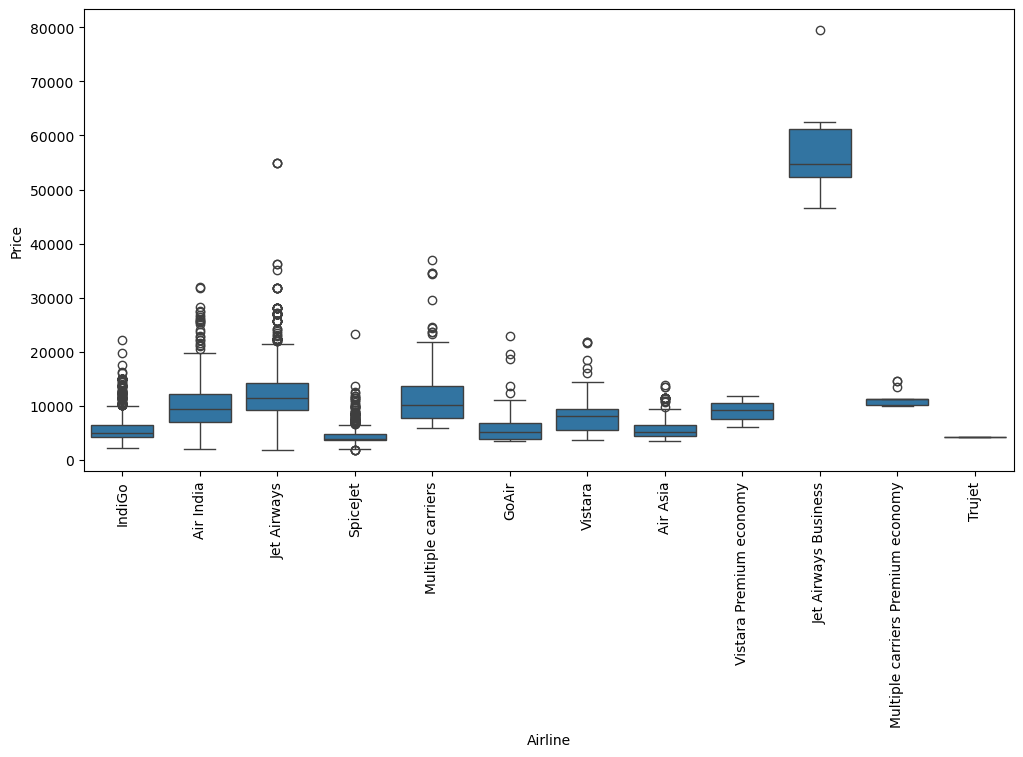

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Airline",y="Price",data=data)
plt.xticks(rotation=90)
plt.show()

#### INSIGHT
Jet Airways and Air India flights are generally more expensive.

### Total Stops vs Price

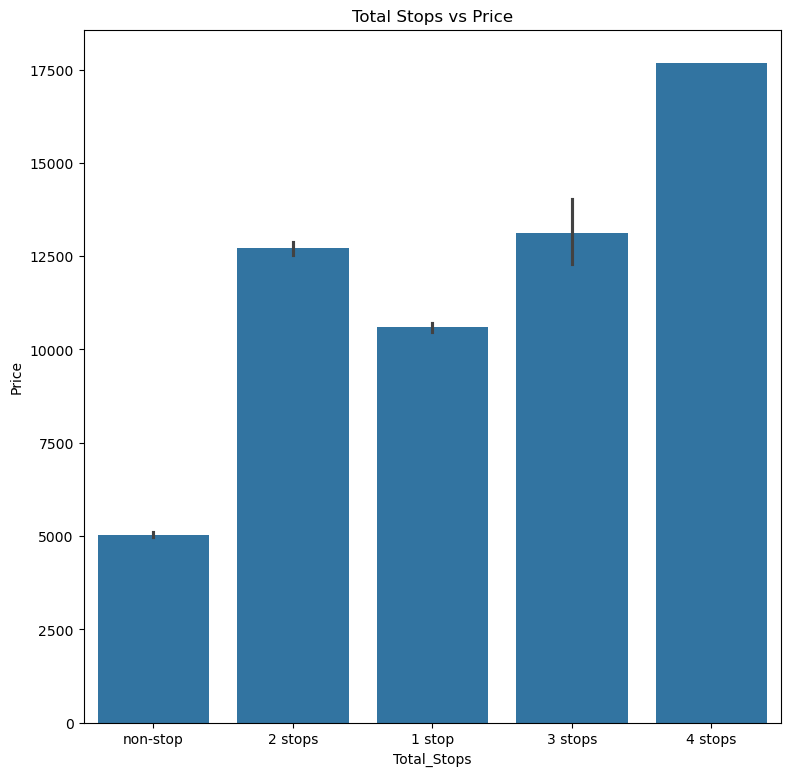

In [18]:
plt.figure(figsize=(9,9))
sns.barplot(x="Total_Stops",y="Price",data=data)
plt.title("Total Stops vs Price")
plt.show()

####  INSIGHT
Flight ticket prices vary based on the number of stops. Flights with 4 stops have the highest average ticket prices, while non-stop flights have comparatively lower prices in this dataset.

## 6) FEATURE ENGINEERING

### Date Feature Extraction

In [19]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [20]:
data['Journey day']=pd.to_datetime(data.Date_of_Journey,format="%d/%m/%Y").dt.day

In [21]:
data['Journey month']=pd.to_datetime(data['Date_of_Journey'],format="%d/%m/%Y").dt.month

In [22]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey day,Journey month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [23]:
data.drop(['Date_of_Journey'],axis=1,inplace=True)

In [24]:
data['Dep_hour']=pd.to_datetime(data['Dep_Time']).dt.hour

In [25]:
data['Dep_min']=pd.to_datetime(data['Dep_Time']).dt.minute

In [26]:
data.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey day,Journey month,Dep_hour,Dep_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


In [27]:
data.drop(["Dep_Time"],axis=1,inplace=True)

In [28]:
data['Arrival_hour']=pd.to_datetime(data['Arrival_Time']).dt.hour


In [29]:
data['Arrival_min']=pd.to_datetime(data['Arrival_Time']).dt.minute

In [30]:
data.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey day,Journey month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


In [31]:
data.drop(['Arrival_Time'],axis=1,inplace=True)

In [32]:
duration=list(data['Duration'])

In [33]:
for i in range(len(duration)):
    if len(duration[i].split()) != 2:    
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   
        else:
            duration[i] = "0h " + duration[i]          

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0])) 
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))

In [34]:
data['Duration_hours']=duration_hours

In [35]:
data['Duration_mins']=duration_mins

In [36]:
data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey day,Journey month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35,4,45


In [37]:
data.drop(['Duration'],axis=1,inplace=True)

In [38]:
data['Total_minutes']=(data['Duration_hours']*60+data['Duration_mins'])

#### INSIGHT
New numerical features were extracted from date, departure time, arrival time, and duration columns. These features help machine learning models understand the data more effectively and improve prediction performance.

### 7) DATA ENCODING

In [39]:
# As Airline is Nominal Categorical data we will perform OneHotEncoding
Airline = data[["Airline"]]
Airline = pd.get_dummies(Airline, drop_first= True , dtype=int)

In [40]:
# As Source is Nominal Categorical data we will perform OneHotEncoding
Source = data[["Source"]]
Source = pd.get_dummies(Source ,drop_first=True , dtype = int)

In [41]:
# As Destination is Nominal Categorical data we will perform OneHotEncoding
Destination = data[["Destination"]]
Destination = pd.get_dummies(Destination, drop_first = True , dtype = int)

In [42]:
data['Route'].value_counts()

Route
DEL → BOM → COK                      2377
BLR → DEL                            1552
CCU → BOM → BLR                       979
CCU → BLR                             724
BOM → HYD                             621
                                     ... 
BOM → VNS → DEL → HYD                   1
BLR → HBX → BOM → NAG → DEL             1
BLR → BOM → IXC → DEL                   1
BLR → CCU → BBI → HYD → VGA → DEL       1
BOM → BBI → HYD                         1
Name: count, Length: 128, dtype: int64

In [43]:
data["Additional_Info"].value_counts()

Additional_Info
No info                         8345
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [44]:
data.drop(['Route','Additional_Info'],axis=1,inplace=True)

In [45]:
data["Total_Stops"].value_counts()

Total_Stops
1 stop      5626
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [46]:
data.replace({"non-stop" : 0, "1 stop":1 , "2 stops":2 , "3 stops":3 , "4 stops":4}, inplace =True)

In [47]:
data["Total_Stops"].dtype

dtype('int64')

In [48]:
data["Total_Stops"].unique()

array([0, 2, 1, 3, 4])

In [49]:
# Concatenate dataframe --> df + Airline + Source + Destination
data= pd.concat([data,Airline,Source,Destination], axis = 1 )

In [50]:
data.head()

,Airline,Source,Destination,Total_Stops,Price,Journey day,Journey month,Dep_hour,Dep_min,Arrival_hour,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,...,0,0,0,0,0,0,0,0,0,1
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,...,0,0,0,1,0,0,0,0,0,0
2,Jet Airways,Delhi,Cochin,2,13882,9,6,9,25,4,...,0,0,1,0,0,1,0,0,0,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,...,0,0,0,1,0,0,0,0,0,0
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,...,0,0,0,0,0,0,0,0,0,1


In [51]:
data.drop(["Airline","Source","Destination"], axis = 1 , inplace =True)

#### INSIGHT
Categorical columns were converted into numerical format for machine learning models.

---
# TASK 2 : MODEL BUILDING
---

### 8) DATA PREPARATION 

In [52]:
x = data.drop("Price",axis=1)
y = data["Price"]

#### INSIGHT
Features (X) and target variable (y) were separated for model building.

### 9) TRAIN TEST SPLIT

In [53]:
x_train , x_test , y_train ,y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

#### INSIGHT
Data was split into training and testing sets to evaluate model performance on unseen data.

### 10) MODEL EVALUATION FUNCTION

In [54]:
def evaluate_model(model,x_test ,y_test ):
    y_pred = model.predict(x_test)

    print("R2 score:", r2_score(y_test,y_pred))
    print("MAE:",mean_absolute_error(y_test,y_pred))
    print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
    print("-" * 40 )

#### INSIGHT

A reusable evaluation function was created to measure the performance of different machine learning models using R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

This helped in comparing multiple models efficiently and selecting the best-performing model.

### 11) LINEAR REGRESSION MODEL

In [55]:
lr = LinearRegression()
lr.fit(x_train,y_train)
print("linearRegression performance:")
evaluate_model(lr, x_test ,y_test)

linearRegression performance:
R2 score: 0.6149437405187846
MAE: 1982.6723766693253
RMSE: 2854.7009659835785
----------------------------------------


#### INSIGHT
Linear Regression showed lower accuracy because it could not capture complex relationships between features and flight prices.

### 12) DECISION TREE REGRESSOR

In [56]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

print("Decision Tree Performance:")
evaluate_model(dt, x_test, y_test)

Decision Tree Performance:
R2 score: 0.7232233791810916
MAE: 1362.401154266105
RMSE: 2420.266722495108
----------------------------------------


#### INSIGHT
Decision Tree Regressor performed better than Linear Regression by handling non-linear patterns in the dataset.

### 13) RANDOM FOREST REGRESSOR

In [57]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

print("Random Forest Performance:")
evaluate_model(rf,x_test,y_test)

Random Forest Performance:
R2 score: 0.8072247014636047
MAE: 1186.2147069178548
RMSE: 2019.8737273893785
----------------------------------------


#### INSIGHT
Random Forest Regressor achieved the highest accuracy and lowest error values among all models.

### 14) XGBREGRESSOR

In [61]:
 !pip install xgboost

In [62]:
from xgboost import XGBRegressor

In [63]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(x_train, y_train)

print("XGBoost Performance:")
evaluate_model(xgb, x_test, y_test)

XGBoost Performance:
R2 score: 0.8315227627754211
MAE: 1273.2215576171875
RMSE: 1888.292019259733
----------------------------------------


#### INSIGHT
XGBRegressor achieved the highest R² Score and lowest error values among all models.

---
# 15) BEST MODEL FOR PRODUCTION
---
XGBRegressor is selected as the best model for production because it achieved the highest prediction accuracy and lowest error rates. It handled complex relationships in the dataset efficiently and provided better generalization performance on unseen data.

# 16) Report on Challenges Faced

### During the project implementation, several challenges were faced while preprocessing and analyzing the dataset.
1. Missing Values
- Challenge: Some columns contained missing values.
- Solution: Used dropna() method to remove null values.
- Reason: Machine learning models cannot work properly with missing data.

2. Categorical Data
- Challenge: Columns like Airline, Source, and Destination contained text values.
- Solution: Used One Hot Encoding (pd.get_dummies()).
- Reason: Machine learning models require numerical data.

3. Duration Column Format
- Challenge: Duration column was in text format like 2h 50m.
- Solution: Separated hours and minutes into numerical values.
- Reason: Numerical features improve model learning.

### 17) CONCLUSION

In this project, flight fare data was analyzed using Exploratory Data Analysis (EDA) and multiple machine learning models were developed for flight price prediction.

The analysis showed that factors such as airline, duration, total stops, source, and destination significantly affect flight ticket prices.

Different regression models including Linear Regression, Decision Tree Regressor, Random Forest Regressor, and XGBRegressor were trained and evaluated.

Among all models, XGBRegressor achieved the best performance with highest accuracy and lowest error values.

This project successfully demonstrated how machine learning can be used to predict future flight ticket prices and help customers plan their journeys more efficiently.